#### Silhouette Scoring

Silhouette Scoring is an evaluation metric used for evaluation of clusters in an unsupervised clustering algorithm.


#### Silhouette Scoring Interpretation

| Score       | Meaning              |
| ----------- | -------------------- |
|  < 0.25     | Poor    Clustering   |
|  0.25 - 0.5 | Average Clustering   |
|  0.5  - 0.7 | Good    Clustering   |
|  > 0.7      | Excellent Clustering |

#### Perform Silhouette Scoring on K-Means Algorithm

K-Means Algorithm is an unsupervised machine learning algorithm that is used to divide the dataset into k number of clusters based on the similar input  features.

Silhouette Scoring is performed on the K-Means Clustering so as to evaluate the quality of 'K' number of clusters.


#### Step 1: Import all the necessary libraries

In [1916]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import train_test_split
from    sklearn.preprocessing   import StandardScaler
from    sklearn.cluster         import KMeans
from    sklearn.metrics         import silhouette_score

#### Step 2: Load the dataset

In [1917]:
df = pd.read_csv("Mall_Customers_dataset.csv")

In [1918]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains about all the details of the customer with their "Annual Income" and their "Spending Score".

#### Step 3: Perform the Data Exploration

In [1919]:
#### get the top five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [1920]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [1921]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [1922]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [1923]:
#### get the columns used in the dataset
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [1924]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [1925]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above dataset explains about the descriptive statistics for all the numerical columns used in the dataset.

In [1926]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above dataset explains about the descriptive statistics for all the categorical columns used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1927]:
#### To check for the NULL records used in the dataset

df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### OBSERATIONS:

1.  There are no NULL records used in the dataset.

In [1928]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [1929]:
#### Replace the column name "Genre" to "Gender" in the dataset

df.rename(columns={"Genre"                  :   "Gender",
                   "Annual Income (k$)"     :   "Annual_Income",
                   "Spending Score (1-100)" :   "Spending_Score"},
                   inplace=True)

In [1930]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The column name 'Genre' has been replaced by 'Gender' in the dataset.

In [1931]:
#### Drop the column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [1932]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The column name "CustomerID" has been removed from the dataset.

In [1933]:
#### perform LabelEncoding on the Gneder column in the dataset

from sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object of Label Encoder, transform the Gender column

df['Gender'] = label.fit_transform(df['Gender'])

In [1934]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  After applying label encoding on Gender column:

    (a.)    Male =================>    1

    (b.)    Female ===============>    0

In [1935]:
#### To check for the NULL records used in the revised dataset

df.isnull().sum()

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the reised dataset.

In [1936]:
#### To check for the duplicate records in the revised dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records in the revised dataset.

#### Step 5: Perform Exploratory Data Analysis

In [1937]:
#### get the correlation between all the columns in the dataset

df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [1938]:
df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table represents the  representation of the correlation between all the numerical column with respect to each other in the datset.

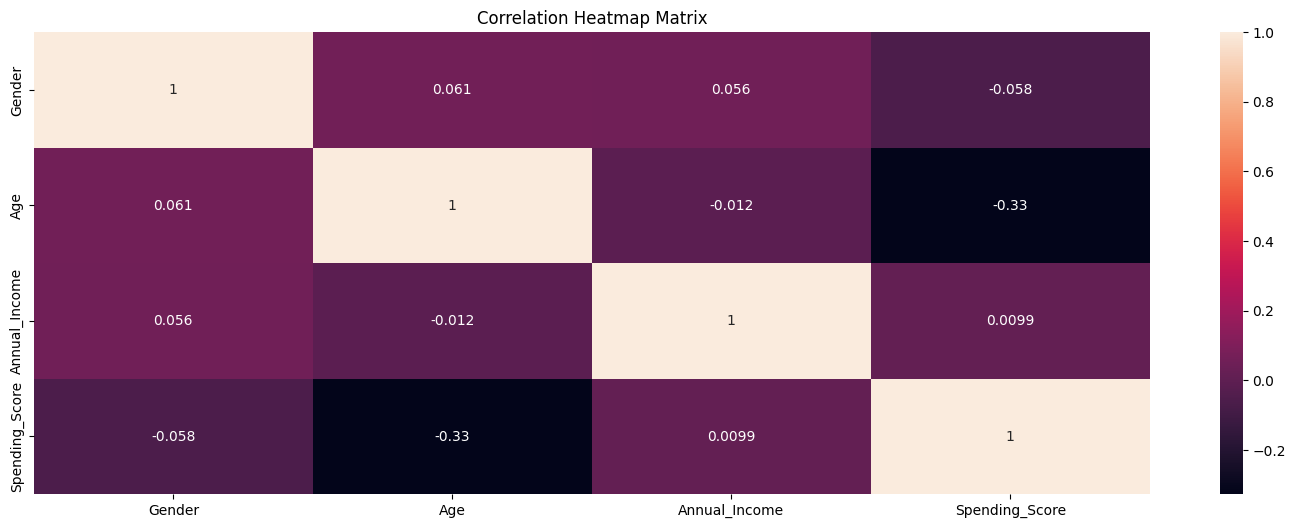

In [1939]:
#### To provide the graphical representation between all the columns in the datset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above table represents the graphical representation of the correlation between all the numerical column with respect to each other in the datset.

2.  The correlation between the Gender and Age is very high

3.  The correlation between the ge and the spending score is the minimum.

#### Step 6: Select the Releant Features from the dataset

In [1940]:
X = df[["Annual_Income","Spending_Score"]]

In [1941]:
print(X)

     Annual_Income  Spending_Score
0               15              39
1               15              81
2               16               6
3               16              77
4               17              40
..             ...             ...
195            120              79
196            126              28
197            126              74
198            137              18
199            137              83

[200 rows x 2 columns]


#### OBSERVATIONS:

1.  The two necessary columns named "Annual_Income" and the "Spending_Score" were selected from the dataset.

#### Step 7: Perform the data visualization based on the features selected

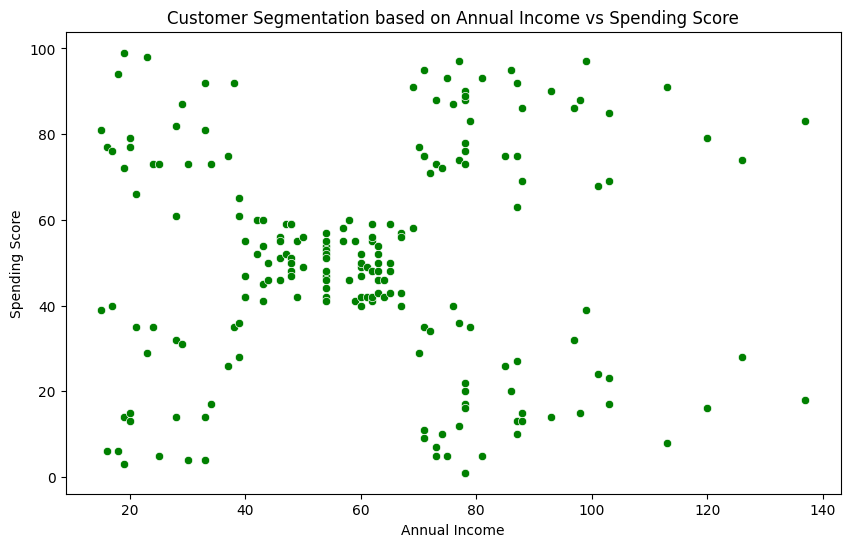

In [1942]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual_Income',y='Spending_Score',data=X,color='green')
plt.title("Customer Segmentation based on Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

#### OBSERVATIONS:

1.  The above figure represents the data visualization of the Customer Segmentation based on Annual Income s Spending Score

2.  In the figure, nearly five clusters are formed in the dataset.

#### Step 8: Perform Feature Scaling on the inputs

In [1943]:
from sklearn.preprocessing import StandardScaler

#### create an object for StandardScaler

sc = StandardScaler()

#### using the object of Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

#### OBSERVATIONS:

1.  All the input features have been scaled in the same range of the inputs between -1 to 1

#### Step 9: Find out the optimal value of KClusters using Elbow method

#### Elbow method:---

It is one of the most imporatnt technique used in K-Means Clustering where we need to find out the optimal 'K' number of clusters that is suitable to form clusters in a machine learning model.


#### WCSS:-----

1.  WCSS stands for Within Clusters sum of squares. It is used to find out the distance of each and every data point with respect to the centroid value.

2.  (a.)    Lower the value of WCSS ==================>   better clusters are formed

    (b.)    Higher the alue o WCSS  ==================>   poor clusters are formed.

In [1944]:
#### initialize the wcss list

wcss = []

#### Take a for loop for the clusters from 2 to 20

for i in range(2,20):
    #### initialize the kmeans cluster object
    kmeans = KMeans(
        n_clusters      = i                  ,
        init            = 'k-means++'        ,
        random_state    =   42
    )

    #### Train the K-Means model with the training data
    kmeans.fit(X_scaled)

    #### add the wcss value to the list
    wcss.append(kmeans.inertia_)

In [1945]:
print(wcss)

[273.66888662642015, 157.70400815035947, 109.22822707921347, 65.56840815571681, 60.13287487193422, 49.66824483736798, 37.319122878338824, 32.49508119910091, 30.05932269404221, 26.76120176636121, 26.23289376978684, 23.1935534219784, 21.195257238649535, 18.179104849335395, 16.082488779041753, 15.242557975456652, 14.618057440193684, 13.888437923082986]


#### OBSERATIONS:

1.  wcss empty list has been initailized that will store all the values of wcss obtained from kmeans

2.  Then  we have considered a for loop from k = 2 till 20

    (a.)    For each time , we are considering 'k' number of clusters, we are creating an object for kmeans  with parameters as follows :----

            (i.)    n_clusters = i =================>  Total number of clusters we are considering each time in a for loop

            (ii.)   init = 'k-means++'  ============>  Small centroid Initialization. Each time we are considering a cluster, we are initializing a small centroid value

            (iii.)  random_state = 42  ============>   ensures reproducibility.


    With this or each cluster , we are creating an object for K-Means


3.  Then we are training the data using the object or K-Means and obtaining the wcss value using kmeans.inertia_

4.  We are appending the wcss value to the empty list.

#### Step 10: Plot the Elbow Curve

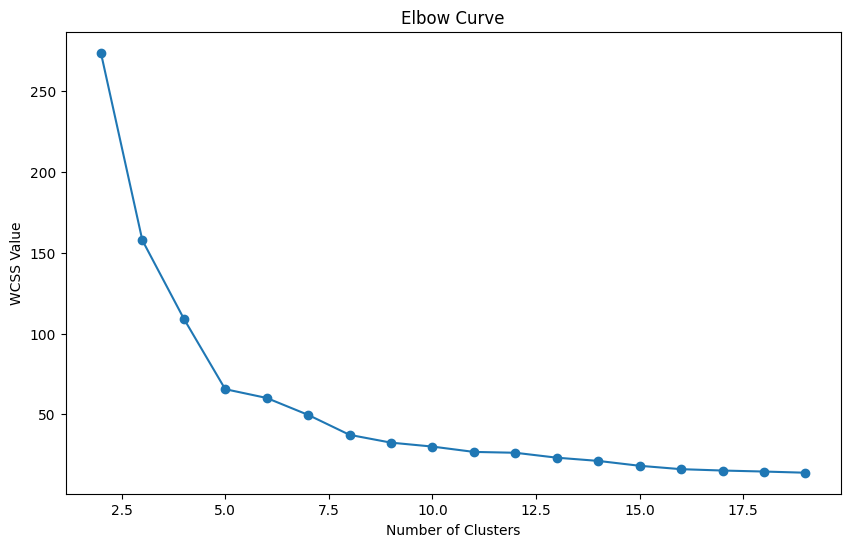

In [1946]:
plt.figure(figsize=(10,6))
#### plot the elbow curve
plt.plot(range(2,20), wcss, marker='o')
#### give the title of the graph
plt.title("Elbow Curve")
#### give the x axis of the graph
plt.xlabel("Number of Clusters")
#### give the y axis of the graph
plt.ylabel("WCSS Value")
#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the Elbow Curve of K-Means Clustering.

2.  As the number of Clusters increases, the WCSS Value decreases.

3.  There is a sharp reduction in WCSS Value with the increase in the number of clusters.

4.  But at K=5, the sharp reduction in WCSS Value gradually becomes clow and the graph becomes stable.

5.  So the optimal number of clusters for the Mall_Customers_dataset using K-Means Clustering algorithm is 5.

#### Step 11: Train the K-Means Model

In [1947]:
#### Create an object for kmeans

kmeans = KMeans(
    n_clusters      =       5               ,
    init            =   'k-means++'         ,
    random_state    =      42
)


#### Train the K-Means model

kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

#### OBSERVATIONS:

(i.)    The object for k-means has been initialized with the help of the following parameters :----

        (a.)    n_clusters ===========>   Total number of clusters to be formed

        (b.)    init       ===========>   K-Means Centroid Initialization

        (c.)    random state ========>    ensures reproducibility

(ii.)   The KMeans model has been trained with the training data

#### Step 12: Predict the Clusters for the K-Means Model

In [1948]:
Y_kmeans_labels = kmeans.predict(X_scaled)

In [1949]:
Y_kmeans_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

#### OBSERATIONS:

1.  We have obtained the labels for the clustering dataset of Malls_Customers 

#### Step 13: Add the Clusters to the dataset

In [1950]:
df['Cluster'] = Y_kmeans_labels

In [1951]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


#### OBSERVATIONS:

1.  After performing K-Means Clustering on the dataset, we hae seen that all the clusters are formed on the given dataset.

#### OBSERVATIONS:

1.  The dataset has all the details of the Customers like as follows :-----

    (a.)    Gender ===============>  Gender of the customer 

    (b.)    Age    ===============>  Age    of the customer

    (c.)    Annual_Income =========>  Annual Income of the customer

    (d.)    Spending_Score ========>  Spending Score of the customer

    (e.)    Cluster_Labels =========>  Labels for the customers

#### Step 14: Again perform Data Exploration on the new dataset

In [1952]:
#### get the length of the new dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [1953]:
#### get the shape of the new dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [1954]:
#### To check for the NULL records used in the new dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
Cluster           0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the new dataset

In [1955]:
#### To check for the duplicate records in the new dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score,Cluster


#### OBSERVATIONS:

1.  There are no duplicate records in the new dataset.

#### Step 15: Visualize the Cluster Labels

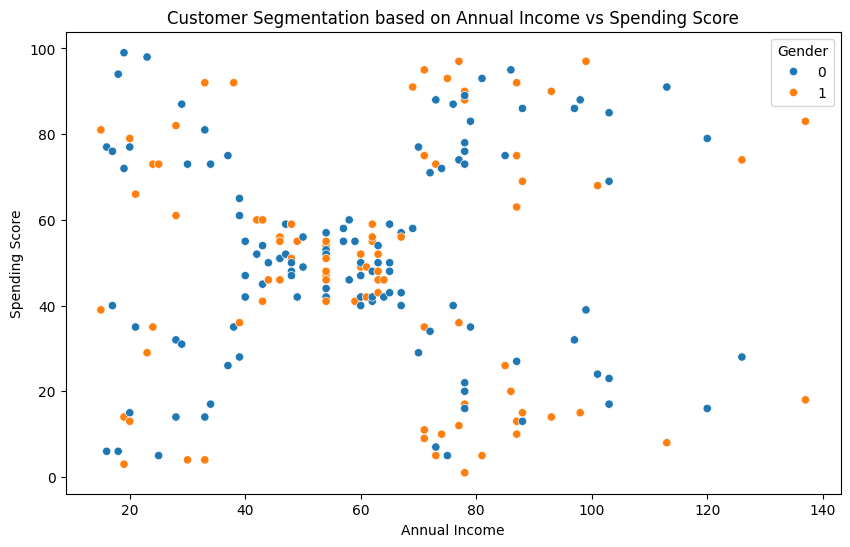

In [1956]:
plt.figure(figsize = (10,6))


#### perform the scatter plot
sns.scatterplot(x='Annual_Income', y= 'Spending_Score', data = df, hue='Gender')

#### Give the title of the graph
plt.title("Customer Segmentation based on Annual Income vs Spending Score")

#### Give the x label of the graph
plt.xlabel("Annual Income")

#### Give the y label of the graph
plt.ylabel("Spending Score")

#### Display the graph
plt.show()

In [1957]:
df['Gender'].value_counts()

Gender
0    112
1     88
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The above graph depicts about the Customer Segmentation of Annual Income vs Spending Score for various Male and Feamle Customers.

2.  The above graph also explains about 

        (a.)    Customers with High Annual Income with High Spending Scores

        (b.)    Customers with High Annual Income with Low Spending Scores

        (c.)    Customers with Low  Annual Income with High Spending Scores

        (d.)    Custoners with Low  Annual Income with Low Spending Scores


3.  In the above graph, we can see that the emale Customers have better annula income and speanding score than the male customers.

#### Step 16: Work with centroids

In [1958]:
#### Obtain the centroids for all the clusters

centroids = kmeans.cluster_centers_

print("Centroids for all the clusters are :", centroids)

Centroids for all the clusters are : [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


#### OBSERVATIONS:

1.  kmeans.cluster_centers_ =============>  obtains the centroid values for all the custers.

2.  But the centroid values are all in the scaled form.

3.  We need to convert the scaled form of the centroids to the original form.

In [1959]:
#### Get all the centroids to their original form

original_centroids = sc.inverse_transform(centroids)

In [1960]:
original_centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

#### OBSERVATIONS:

1.  All the centroids in the scaled form have been conerted to their original values.

#### Step 16: Plot the Centroids

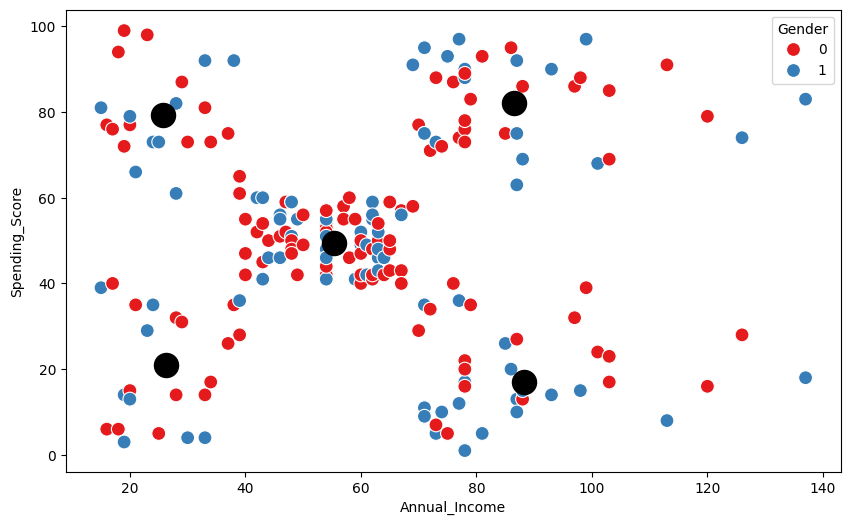

In [1961]:
plt.figure(figsize=(10,6))

#### Plot the original data points
sns.scatterplot(x=df['Annual_Income'],y=df['Spending_Score'],hue=df['Gender'],palette='Set1',s=100)

#### Plot the centroids
plt.scatter(
    original_centroids[:,0]                             ,
    original_centroids[:,1]                             ,
    s               =           300                     ,
    c               =           'black'                 ,
    marker          =           'o'                     ,
    label           =           'centroids'
)

#### OBSERVATIONS:

1.  The above dataset explains about the customer details for the Annual_Income vs Spending_Score.

2.  There are a total of five clusters formed in the dataset.

3.  For each and every cluster, centroids are formed for each and every cluster.

4.  There are a total of 5 centroids formed in 5 each clusters.

#### Step 17: Evaluate the Silhouette metrics

In [1962]:
from    sklearn.metrics import silhouette_score

#### Get the silhouette score for the quality of the cluster

scores = silhouette_score(X_scaled, Y_kmeans_labels)

print("Silhouette Scores for the cluster is:", scores)

Silhouette Scores for the cluster is: 0.5546571631111091


#### OBSERVATIONS:

1.  The Silhouette Score for the quality of K-Means Clustering is 0.55 which comes under "Good" Clustering.

#### Silhouette Scoring Interpretation

| Score       | Meaning              |
| ----------- | -------------------- |
|  < 0.25     | Poor    Clustering   |
|  0.25 - 0.5 | Average Clustering   |
|  0.5  - 0.7 | Good    Clustering   |
|  > 0.7      | Excellent Clustering |